# Capstone — A Backtested Forecasting Report
### Riyadh / Grocery daily demand — from raw data to a validated, uncertainty-aware forecast

**Name:** Sarah Aldhawyan  
**Programme:** Time Series Forecasting for AI Systems — Cohort 20 Sept – 22 Sept 2026  
**Dataset:** `data/retail_demand.csv`, filtered to Riyadh / Grocery (daily, 2023-01-01 → 2025-12-31, 1,096 rows)

**Why this series:** it has ~3 years of clean daily history, a stable upward trend, and strong weekly seasonality with occasional promo-style demand shocks — enough real structure to exercise every technique below.

## 0. Setup

In [ ]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "statsmodels", "lightgbm", "scikit-learn")

In [ ]:
import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout, or download it from GitHub
    if this is a fresh Colab runtime. Same convention every lab in this
    course uses, so the notebook still works if it's opened straight from
    a Colab badge with nothing checked out locally."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    return float(np.sum(np.abs(y_true - np.asarray(y_pred))) / np.sum(np.abs(y_true)) * 100)


def mase(y_true, y_pred, y_train, seasonal_period=7):
    """Scaled against THIS fold's own in-sample seasonal-naive error, so a
    calmer or noisier training window gets its own yardstick."""
    y_train = np.asarray(y_train)
    naive_errors = np.abs(y_train[seasonal_period:] - y_train[:-seasonal_period])
    scale = np.mean(naive_errors)
    return float(mae(y_true, y_pred) / scale) if scale else float("nan")


def coverage(y_true, lower, upper):
    y_true = np.asarray(y_true)
    inside = (y_true >= np.asarray(lower)) & (y_true <= np.asarray(upper))
    return float(np.mean(inside))


def interval_width(lower, upper):
    return float(np.mean(np.asarray(upper) - np.asarray(lower)))


def seasonal_naive_forecast(y_train, horizon, period=7):
    """The floor every model below has to beat: repeat the last observed
    weekly cycle forward. No fitting, no parameters to get wrong."""
    y_train = np.asarray(y_train)
    last_cycle = y_train[-period:]
    reps = int(np.ceil(horizon / period))
    return np.tile(last_cycle, reps)[:horizon]

## Load the series

1096 daily rows, 2023-01-01 -> 2025-12-31
missing after asfreq: 0


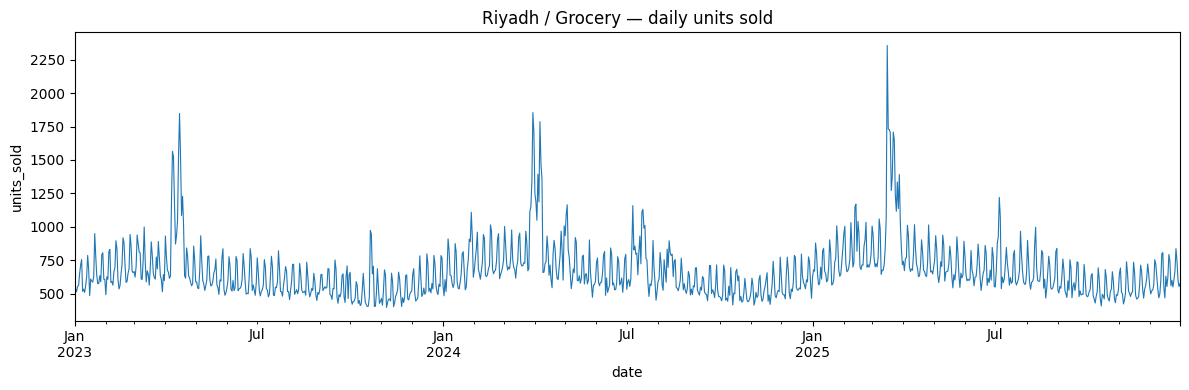

In [ ]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
series = (
    df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")]
    .set_index("date")["units_sold"]
    .asfreq("D")
    .sort_index()
)
SERIES_START = series.index[0]

print(f"{len(series)} daily rows, {series.index.min().date()} -> {series.index.max().date()}")
print(f"missing after asfreq: {series.isna().sum()}")

fig, ax = plt.subplots(figsize=(12, 4))
series.plot(ax=ax, linewidth=0.8)
ax.set_title("Riyadh / Grocery — daily units sold")
ax.set_ylabel("units_sold")
plt.tight_layout()
plt.show()

Looking at the plot, there's a slow upward climb across the three years, plus a clear weekly rhythm — certain days are consistently higher, others consistently lower, week after week. What stands out most are a couple of short but massive spikes, especially mid-March 2025 and mid-April 2023, where values jump way past anything else in the series. Those turned out to be exactly the days STL flagged as the biggest residuals below.

---
## Section 1 — Time Series Structure & Diagnostics
Decomposition, ACF/PACF, and a stationarity check — the goal is to leave this section knowing whether, and how, the series needs differencing before Section 2's classical model.

### 1.1 STL decomposition

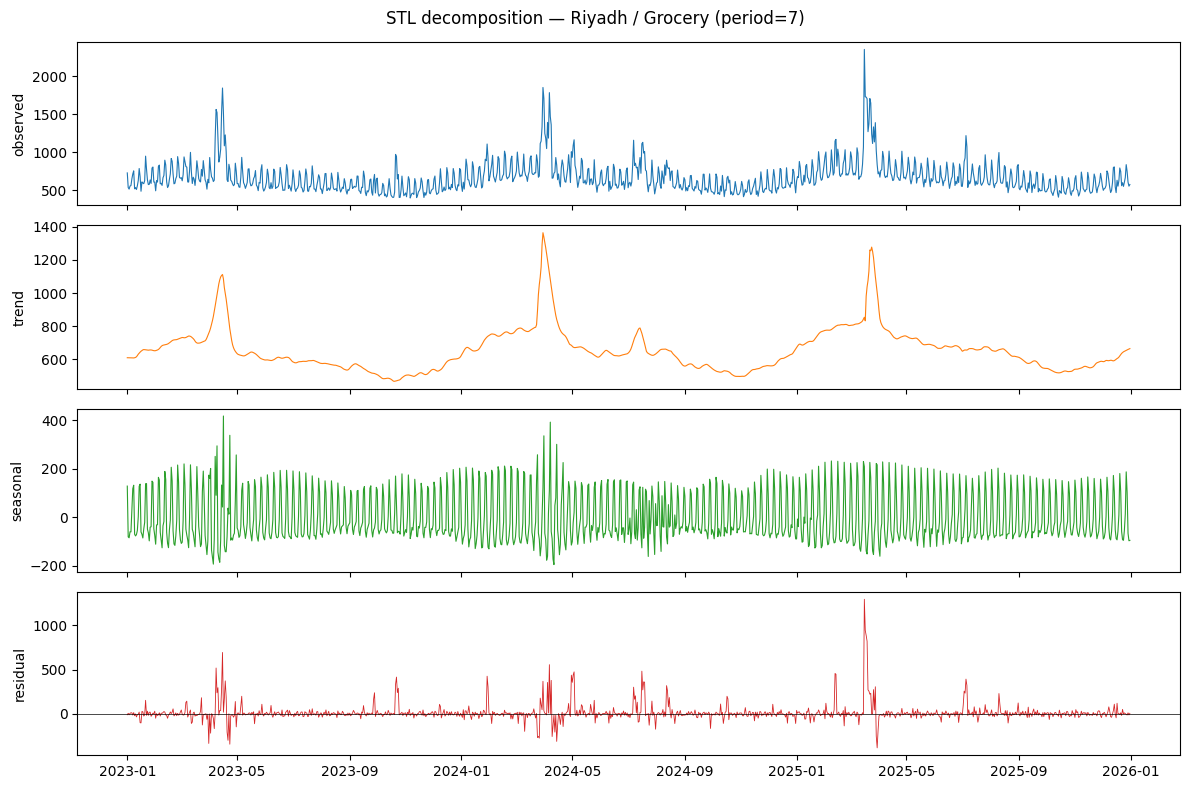

5 largest |residual| days:
date
2025-03-16    1293.844161
2025-03-17     942.499865
2025-03-18     885.541233
2025-03-19     819.675148
2023-04-15     693.547435
Name: resid, dtype: float64


In [ ]:
from statsmodels.tsa.seasonal import STL

stl_result = STL(series, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(series.index, series.values, linewidth=0.8); axes[0].set_ylabel("observed")
axes[1].plot(series.index, stl_result.trend, linewidth=0.8, color="tab:orange"); axes[1].set_ylabel("trend")
axes[2].plot(series.index, stl_result.seasonal, linewidth=0.8, color="tab:green"); axes[2].set_ylabel("seasonal")
axes[3].plot(series.index, stl_result.resid, linewidth=0.6, color="tab:red"); axes[3].axhline(0, color="black", linewidth=0.5)
axes[3].set_ylabel("residual")
fig.suptitle("STL decomposition — Riyadh / Grocery (period=7)")
plt.tight_layout()
plt.show()

print("5 largest |residual| days:")
print(stl_result.resid.abs().sort_values(ascending=False).head(5))

The trend climbs over the three years but not smoothly — it has its own ups and downs along the way, so overall demand is growing, just unevenly. The seasonal component repeats identically every week, which makes sense since STL was forced into a 7-day period.


The interesting part is the residual. The five biggest residual days aren't scattered randomly across three years — they're two tight clusters: March 16–19, 2025, and April 15, 2023, about a year apart. Both fall inside Ramadan for their respective year (Ramadan 2025 was roughly Feb 28 – Mar 29, and Ramadan 2023 was roughly Mar 22 – Apr 20), which fits with the stock-up shopping that usually happens then. That's a real, recurring event, but it doesn't land on the same calendar date every year, so a fixed weekly decomposition has no way to absorb it — STL correctly leaves it in the residual instead of forcing it into "noise." 

### 1.2 ACF / PACF — raw vs. differenced

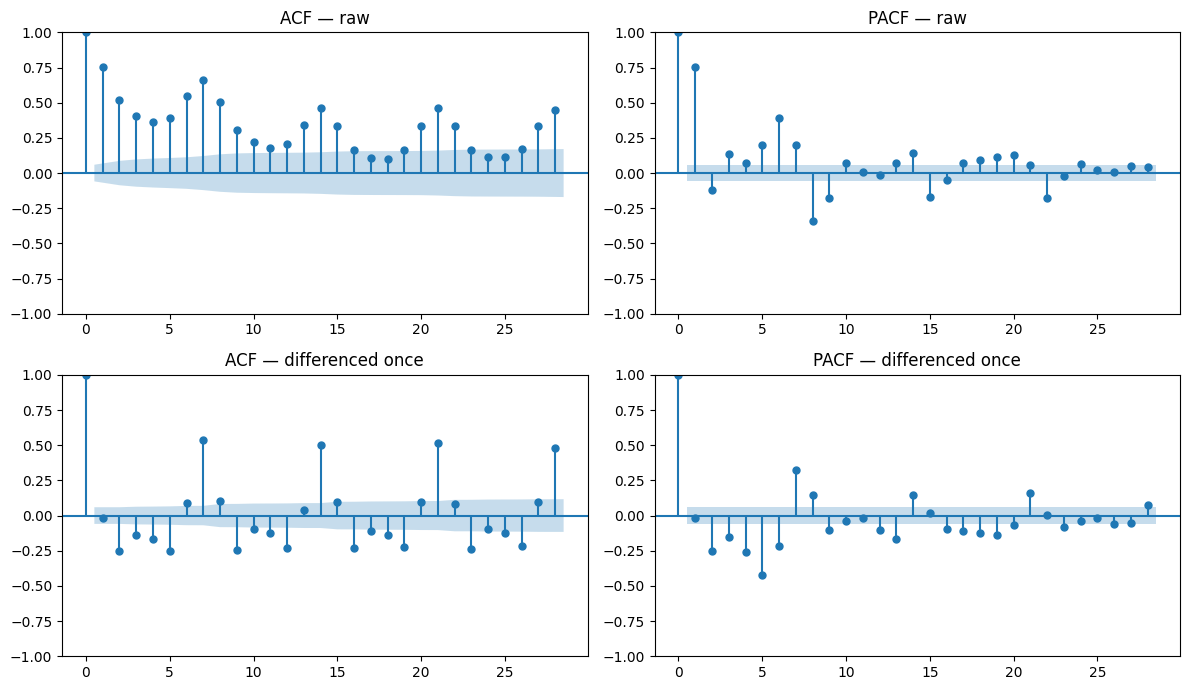

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diffed = series.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(series, lags=28, ax=axes[0, 0]); axes[0, 0].set_title("ACF — raw")
plot_pacf(series, lags=28, ax=axes[0, 1], method="ywm"); axes[0, 1].set_title("PACF — raw")
plot_acf(diffed, lags=28, ax=axes[1, 0]); axes[1, 0].set_title("ACF — differenced once")
plot_pacf(diffed, lags=28, ax=axes[1, 1], method="ywm"); axes[1, 1].set_title("PACF — differenced once")
plt.tight_layout()
plt.show()

The raw ACF decays slowly and keeps spiking at 7, 14, 21, 28 — that slow decay on its own is a sign the series isn't stationary, since correlation with the past should die off quickly for a stationary series and here it doesn't. Once I difference the series, that slow decay mostly disappears, but the lag-7 spikes stick around. So plain differencing handles the trend but does nothing for the weekly pattern, which is why Section 2 needs a seasonal term on top of the regular order, not just plain ARIMA.




### 1.3 Augmented Dickey-Fuller test

In [ ]:
from statsmodels.tsa.stattools import adfuller

def report_adf(y, label):
    result = adfuller(y.dropna(), autolag="AIC")
    stat, pvalue, used_lags = result[0], result[1], result[2]
    crit = result[4]
    print(f"{label}")
    print(f"  ADF statistic: {stat:.4f}")
    print(f"  p-value:       {pvalue:.6f}")
    print(f"  used lags:     {used_lags}")
    for level, cv in crit.items():
        print(f"  critical value ({level}): {cv:.4f}")
    verdict = "stationary (reject the unit-root null)" if pvalue < 0.05 else "NON-stationary (fail to reject the null)"
    print(f"  => {verdict}\n")
    return pvalue

pvalue_raw = report_adf(series, "Raw series")
pvalue_diff = report_adf(diffed, "Once-differenced series")

/tmp/ipykernel_2346/2574429260.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(y.dropna(), autolag="AIC")


Raw series
  ADF statistic: -3.8721
  p-value:       0.002250
  used lags:     21
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)

Once-differenced series
  ADF statistic: -9.8473
  p-value:       0.000000
  used lags:     22
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)



/tmp/ipykernel_2346/2574429260.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(y.dropna(), autolag="AIC")


Both p-values come out below 0.05 — 0.00225 for the raw series and basically 0 for the differenced one — so ADF rejects the unit-root null both times and calls both series stationary.


That sounds odd next to a series that's clearly trending upward in the plot, but it's not really a contradiction. `adfuller` with the default settings tests against a constant mean, not a trend, so it's really asking "does this wander off with no anchor at all" rather than "is the level flat." Because the weekly seasonality keeps pulling the series back toward a baseline every few days, it never behaves like a true random walk, so ADF calls it stationary even with a real trend sitting on top of it.


Given that, plus the visible trend and the slow ACF decay from the last section, I'm still going with d=1 into Section 2 rather than trusting the raw ADF result on its own — one test shouldn't overrule three consistent pieces of evidence pointing the other way.

---
## Section 2 — Classical Forecasting Model
One held-out window (last 60 days) to fit and compare a couple of SARIMA candidates plus an exponential-smoothing model, with a residual check on the winner. (Section 4 revisits this with several folds instead of one.)

In [ ]:
HORIZON_S2 = 60
train_s2 = series.iloc[:-HORIZON_S2]
test_s2 = series.iloc[-HORIZON_S2:]
print(f"train: {train_s2.index.min().date()} .. {train_s2.index.max().date()} ({len(train_s2)} days)")
print(f"test:  {test_s2.index.min().date()} .. {test_s2.index.max().date()} ({len(test_s2)} days)")

train: 2023-01-01 .. 2025-11-01 (1036 days)
test:  2025-11-02 .. 2025-12-31 (60 days)


### 2.1 A small SARIMAX order search, chosen by AIC

In [ ]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

p_range = d_range = q_range = range(0, 3)
P_range = D_range = Q_range = range(0, 2)
SEASONAL_PERIOD = 7

search_results = []
for p, d, q in itertools.product(p_range, d_range, q_range):
    for P, D, Q in itertools.product(P_range, D_range, Q_range):
        try:
            fit = SARIMAX(
                train_s2, order=(p, d, q), seasonal_order=(P, D, Q, SEASONAL_PERIOD),
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False)
            search_results.append({"order": (p, d, q), "seasonal_order": (P, D, Q, SEASONAL_PERIOD), "aic": fit.aic})
        except Exception:
            continue

search_df = pd.DataFrame(search_results).sort_values("aic").reset_index(drop=True)
print(f"{len(search_df)} candidate orders converged")
print(search_df.head(8).to_string(index=False))

best_order = search_df.iloc[0]["order"]
best_seasonal_order = search_df.iloc[0]["seasonal_order"]
print(f"\nBest by AIC: order={best_order}, seasonal_order={best_seasonal_order}")

216 candidate orders converged
    order seasonal_order          aic
(1, 1, 2)   (0, 1, 1, 7) 12264.838985
(1, 0, 2)   (1, 1, 1, 7) 12269.368261
(2, 1, 1)   (1, 1, 1, 7) 12270.124682
(2, 1, 2)   (0, 1, 1, 7) 12273.919940
(1, 0, 2)   (0, 1, 1, 7) 12274.515238
(2, 1, 1)   (0, 1, 1, 7) 12275.329406
(2, 0, 2)   (0, 1, 1, 7) 12278.056240
(1, 2, 2)   (0, 1, 1, 7) 12278.316134

Best by AIC: order=(1, 1, 2), seasonal_order=(0, 1, 1, 7)


The winner was SARIMAX(1,1,2)x(0,1,1,7), AIC 12264.84 out of 216 orders that converged. That's close to what I expected from the ACF/PACF read — a short order plus a seasonal term at s=7 — though I expected the seasonal piece to lean more on an AR term, and it actually picked a seasonal MA term instead (P=0, Q=1). That means it's correcting off last week's forecast error rather than last week's raw value, which apparently fits this series slightly better.

### 2.2 Fit the winning SARIMAX and a Holt-Winters model

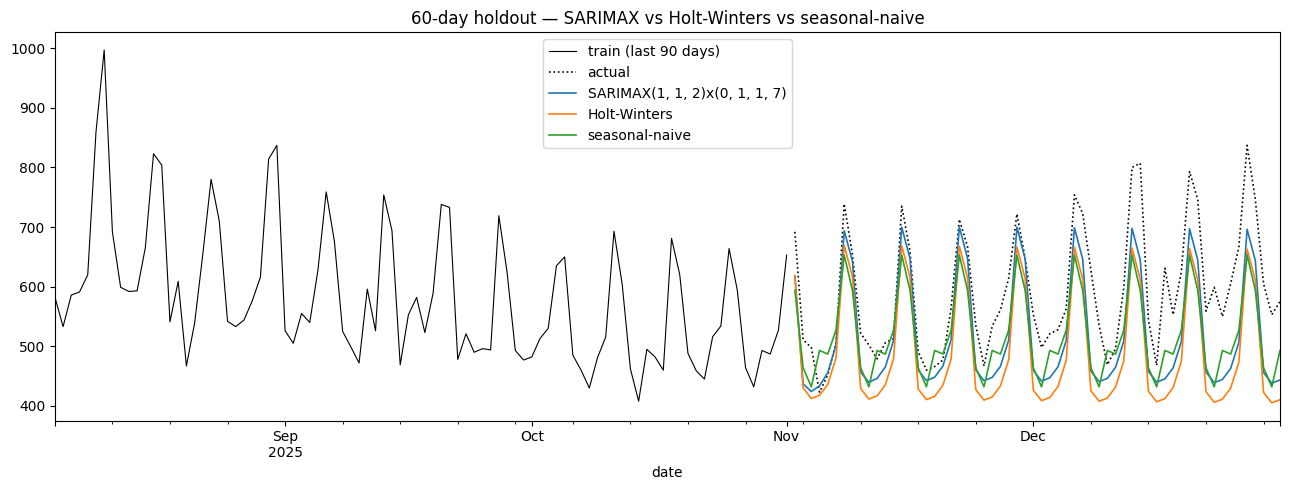

In [ ]:
sarima_fit = SARIMAX(
    train_s2, order=best_order, seasonal_order=best_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)
sarima_forecast = sarima_fit.get_forecast(steps=HORIZON_S2).predicted_mean
sarima_forecast.index = test_s2.index

from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_fit = ExponentialSmoothing(
    train_s2, trend="add", seasonal="add", seasonal_periods=SEASONAL_PERIOD,
).fit()
hw_forecast = hw_fit.forecast(HORIZON_S2)
hw_forecast.index = test_s2.index

naive_forecast = pd.Series(seasonal_naive_forecast(train_s2.values, HORIZON_S2, period=7), index=test_s2.index)

fig, ax = plt.subplots(figsize=(13, 5))
train_s2.iloc[-90:].plot(ax=ax, linewidth=0.8, color="black", label="train (last 90 days)")
test_s2.plot(ax=ax, linewidth=1.2, color="black", linestyle=":", label="actual")
sarima_forecast.plot(ax=ax, linewidth=1.2, label=f"SARIMAX{best_order}x{best_seasonal_order}")
hw_forecast.plot(ax=ax, linewidth=1.2, label="Holt-Winters")
naive_forecast.plot(ax=ax, linewidth=1.2, label="seasonal-naive")
ax.legend(); ax.set_title("60-day holdout — SARIMAX vs Holt-Winters vs seasonal-naive")
plt.tight_layout()
plt.show()

In [ ]:
scores_s2 = []
for name, pred in [("SARIMAX", sarima_forecast.values), ("Holt-Winters", hw_forecast.values), ("seasonal-naive", naive_forecast.values)]:
    scores_s2.append({
        "model": name, "mae": mae(test_s2.values, pred), "rmse": rmse(test_s2.values, pred),
        "wape": wape(test_s2.values, pred), "mase": mase(test_s2.values, pred, train_s2.values, seasonal_period=7),
    })
pd.DataFrame(scores_s2).set_index("model").sort_values("mase")

,mae,rmse,wape,mase
model,,,,
SARIMAX,71.191402,86.264103,12.053061,0.785216
seasonal-naive,78.133333,91.609497,13.228364,0.861783
Holt-Winters,100.993420,113.289564,17.098691,1.113922


### 2.3 Residual diagnostics — Ljung-Box on the winning model

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

winner_resid = sarima_fit.resid  
lb = acorr_ljungbox(winner_resid, lags=[7, 14, 21], return_df=True)
print(lb)

      lb_stat  lb_pvalue
7   12.039271   0.099275
14  31.102099   0.005364
21  36.207879   0.020718


At lag 7 the p-value is 0.099, so it just barely passes. At lag 14 and 21 it's 0.0054 and 0.0207 — both under 0.05, so the model fails there. Since a low p-value here means there's still structure left in the residuals, that's a real gap: something 2–3 weeks out isn't being captured.


I'm keeping SARIMAX anyway since it had the best holdout accuracy in Section 2.2 (MAE 71.2 vs 78.1 for naive and 101.0 for Holt-Winters), but I don't want to hide the Ljung-Box failure just because the accuracy looked good. My best guess for the cause goes back to the Ramadan spikes from Section 1.1 — those don't happen on a fixed weekly schedule, so a (P,D,Q) term built around s=7 simply can't represent them, and that's probably what's leaking into the residuals at the longer lags.

# Section 3 — ML / GBM Forecasting & Feature Engineering


In [ ]:
FEATURE_COLS = ["lag_1", "lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_mean_28", "roll_std_7", "dow", "month"]


def build_features(y: pd.Series) -> pd.DataFrame:
    """One row per date, built only from y.shift(1) onward — so the row
    for date t never sees y[t] itself, only strictly earlier values."""
    feat = pd.DataFrame({"y": y})
    for lag in (1, 7, 14, 28):
        feat[f"lag_{lag}"] = y.shift(lag)
    shifted = y.shift(1)
    feat["roll_mean_7"] = shifted.rolling(7).mean()
    feat["roll_mean_28"] = shifted.rolling(28).mean()
    feat["roll_std_7"] = shifted.rolling(7).std()
    feat["dow"] = feat.index.dayofweek
    feat["month"] = feat.index.month
    return feat.dropna()


train_feats_s3 = build_features(train_s2)
print(f"training rows after warm-up drop: {len(train_feats_s3)} (lost {len(train_s2) - len(train_feats_s3)} rows to the 28-day warm-up)")
train_feats_s3[["y"] + FEATURE_COLS].head()

training rows after warm-up drop: 1008 (lost 28 rows to the 28-day warm-up)


,y,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_28,roll_std_7,dow,month
date,,,,,,,,,,
2023-01-29,806.0,792.0,779.0,680.0,728.0,654.714286,630.607143,92.977980,6,1
2023-01-30,607.0,806.0,637.0,486.0,535.0,658.571429,633.392857,99.335890,0,1
2023-01-31,607.0,607.0,574.0,610.0,514.0,654.285714,635.964286,101.053970,1,1
2023-02-01,492.0,607.0,577.0,595.0,555.0,659.000000,639.285714,97.387542,2,2
2023-02-02,626.0,492.0,635.0,586.0,561.0,646.857143,637.035714,113.312883,3,2


### 3.1 Recursive multi-step forecast — the leakage-critical part

In [ ]:
from lightgbm import LGBMRegressor


def gbm_recursive_forecast(y_train: pd.Series, horizon: int, quantile: float | None = None) -> np.ndarray:
    """Fit fresh on y_train only, then predict one day at a time, feeding
    each prediction back in as history for the NEXT day's lag/rolling
    features. `test_s2` is never touched inside this function."""
    feats = build_features(y_train)
    params = dict(n_estimators=250, num_leaves=15, max_depth=5, learning_rate=0.06, random_state=RNG_SEED, verbosity=-1)
    if quantile is not None:
        params.update(objective="quantile", alpha=quantile)
    model = LGBMRegressor(**params)
    model.fit(feats[FEATURE_COLS], feats["y"])

    working = y_train.copy()
    preds = []
    for _ in range(horizon):
        next_date = working.index[-1] + pd.Timedelta(days=1)
        assert next_date not in working.index
        row = pd.DataFrame([{
            "lag_1": working.iloc[-1], "lag_7": working.iloc[-7], "lag_14": working.iloc[-14], "lag_28": working.iloc[-28],
            "roll_mean_7": working.iloc[-7:].mean(), "roll_mean_28": working.iloc[-28:].mean(), "roll_std_7": working.iloc[-7:].std(),
            "dow": next_date.dayofweek, "month": next_date.month,
        }])[FEATURE_COLS]
        pred = float(model.predict(row)[0])
        preds.append(pred)
        working.loc[next_date] = pred  
    return np.array(preds)


gbm_forecast_s3 = gbm_recursive_forecast(train_s2, HORIZON_S2)

gbm_scores = {
    "MAE": mae(test_s2.values, gbm_forecast_s3), "RMSE": rmse(test_s2.values, gbm_forecast_s3),
    "WAPE": wape(test_s2.values, gbm_forecast_s3), "MASE": mase(test_s2.values, gbm_forecast_s3, train_s2.values, seasonal_period=7),
}
print(gbm_scores)

{'MAE': 50.58586912909055, 'RMSE': 60.56546828069493, 'WAPE': 8.564440722778388, 'MASE': 0.5579443408347179}


The line that matters is `working.loc[next_date] = pred` — the model's own prediction gets appended to history, not the real value from `test_s2`. If that got swapped to read from `test_s2` instead, every later day's lag features would be built off values the model was never actually supposed to know yet. In a real deployment those future values don't exist at forecast time, so doing that would make the backtest look far more accurate than the model could ever really be — it would basically be grading the model on an open-book test.

### 3.2 Which features actually mattered

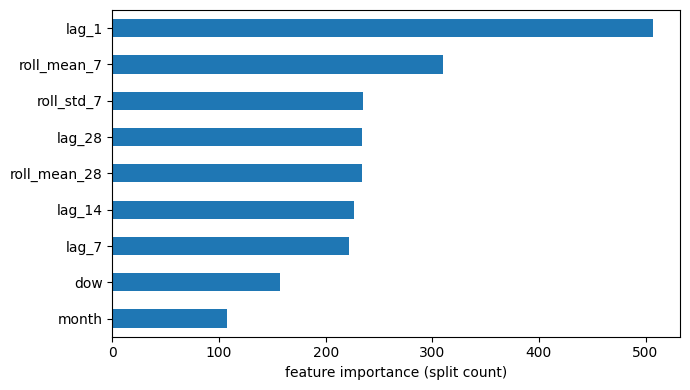

In [ ]:
model_for_importance = LGBMRegressor(n_estimators=250, num_leaves=15, max_depth=5, learning_rate=0.06, random_state=RNG_SEED, verbosity=-1)
model_for_importance.fit(train_feats_s3[FEATURE_COLS], train_feats_s3["y"])

importances = pd.Series(model_for_importance.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax)
ax.set_xlabel("feature importance (split count)")
plt.tight_layout()
plt.show()

`lag_1` is way out in front at around 510 splits, then `roll_mean_7` comes in second at around 310. After that, `roll_std_7`, `lag_28`, and `roll_mean_28` cluster together around 230, `lag_14` and `lag_7` sit a bit lower around 220–225, and `dow` and `month` trail behind at 155 and 105.


Yesterday's value being the top feature makes sense given how noisy this series is day to day — it's leaning hard on "today probably looks like yesterday." But `roll_mean_7` being a clear second says it's not relying on that one day alone; a smoothed weekly average is backing it up, probably so a single unusually high or low day doesn't throw the forecast off too much.

---
## Section 4 — Backtesting Framework & Time-Based Validation
Every model above was checked against exactly one 60-day holdout. This section checks whether that verdict survives being tested against several holdouts instead of one.

### 4.1 Expanding vs. rolling — my choice for this series
I'm using an **expanding window**, not rolling. Riyadh/Grocery has no known structural break (unlike the workforce series) and a full 3 years of consistent weekly + yearly seasonality — older history is still relevant context for the model, not stale or misleading, so there's no reason to throw early history away as the folds advance. Rolling would only earn its place here if I had a specific reason to believe 2023 data actively confuses a model trained today.

In [ ]:
def expanding_window_splits(n, n_folds, horizon, min_train_size):
    """n_folds pairs of (train_slice, test_slice): every fold's test window
    sits immediately after its train window, and the train window grows to
    include everything before it (including earlier folds' test regions,
    which are legitimately in the past by the time a later fold runs)."""
    last_test_end = n
    first_test_start = last_test_end - n_folds * horizon
    if first_test_start < min_train_size:
        raise ValueError("Not enough history for this many folds/horizon/min_train_size.")
    splits = []
    for i in range(n_folds):
        test_start = first_test_start + i * horizon
        test_end = test_start + horizon
        splits.append((slice(0, test_start), slice(test_start, test_end)))
    return splits


def run_backtest(y, splits, fit_predict_fn):
    """Call fit_predict_fn fresh, once per fold, handing it ONLY that
    fold's own y_train -- never a later fold's data, never a model object
    reused across folds."""
    y = np.asarray(y)
    results = []
    for i, (train_slice, test_slice) in enumerate(splits):
        y_train, y_true = y[train_slice], y[test_slice]
        y_pred = np.asarray(fit_predict_fn(y_train, len(y_true)))
        results.append({"fold": i, "y_train": y_train, "y_true": y_true, "y_pred": y_pred})
    return results

### 4.2 Build the folds and wrap each model as a `fit_predict_fn`

In [ ]:
N_FOLDS = 5
HORIZON_S4 = 14
MIN_TRAIN_SIZE = 730  

splits = expanding_window_splits(n=len(series), n_folds=N_FOLDS, horizon=HORIZON_S4, min_train_size=MIN_TRAIN_SIZE)
for i, (tr, te) in enumerate(splits):
    print(f"fold {i}: train={tr.stop:4d} days  |  test {series.index[te.start].date()} -> {series.index[te.stop-1].date()}")

fold 0: train=1026 days  |  test 2025-10-23 -> 2025-11-05
fold 1: train=1040 days  |  test 2025-11-06 -> 2025-11-19
fold 2: train=1054 days  |  test 2025-11-20 -> 2025-12-03
fold 3: train=1068 days  |  test 2025-12-04 -> 2025-12-17
fold 4: train=1082 days  |  test 2025-12-18 -> 2025-12-31


In [ ]:
def naive_fit_predict(y_train, horizon):
    return seasonal_naive_forecast(y_train, horizon, period=7)


def hw_fit_predict(y_train, horizon):
    """Fresh Holt-Winters fit per fold; falls back to seasonal-naive if
    the optimizer fails to converge on a thin/unlucky training window."""
    try:
        model = ExponentialSmoothing(y_train, trend="add", seasonal="add", seasonal_periods=7).fit()
        return np.asarray(model.forecast(horizon))
    except Exception:
        return seasonal_naive_forecast(y_train, horizon, period=7)


def gbm_fit_predict(y_train, horizon):
    idx = pd.date_range(start=SERIES_START, periods=len(y_train), freq="D")
    return gbm_recursive_forecast(pd.Series(y_train, index=idx), horizon)


MODELS = {"seasonal_naive": naive_fit_predict, "holt_winters": hw_fit_predict, "lightgbm_recursive": gbm_fit_predict}
backtest_results = {name: run_backtest(series.values, splits, fn) for name, fn in MODELS.items()}
print({name: len(res) for name, res in backtest_results.items()})

{'seasonal_naive': 5, 'holt_winters': 5, 'lightgbm_recursive': 5}


### 4.3 Score every fold, and look at the spread — not just the mean

In [ ]:
rows_s4 = []
for model_name, fold_results in backtest_results.items():
    for r in fold_results:
        rows_s4.append({
            "model": model_name, "fold": r["fold"],
            "mae": mae(r["y_true"], r["y_pred"]), "wape": wape(r["y_true"], r["y_pred"]),
            "mase": mase(r["y_true"], r["y_pred"], r["y_train"], seasonal_period=7),
        })
scores_s4 = pd.DataFrame(rows_s4)
scores_s4.sort_values(["model", "fold"])

,model,fold,mae,wape,mase
5,holt_winters,0,33.995847,6.356061,0.372504
6,holt_winters,1,30.342316,5.528272,0.334957
7,holt_winters,2,37.868537,6.566256,0.421858
8,holt_winters,3,40.524613,6.640269,0.455294
9,holt_winters,4,30.727888,4.772999,0.346608
10,lightgbm_recursive,0,28.331783,5.297075,0.310441
11,lightgbm_recursive,1,27.628739,5.033867,0.305001
12,lightgbm_recursive,2,34.450399,5.973564,0.383780
13,lightgbm_recursive,3,56.601032,9.274514,0.635913
14,lightgbm_recursive,4,40.610947,6.308147,0.458089


In [ ]:
summary_s4 = scores_s4.groupby("model")[["mae", "wape", "mase"]].agg(["mean", "std"])
summary_s4

mae                 wape                mase  \
                         mean        std      mean       std      mean   
model                                                                    
holt_winters        34.691840   4.450515  5.972772  0.803387  0.386244   
lightgbm_recursive  37.524580  11.888255  6.377433  1.698038  0.418645   
seasonal_naive      46.414286  12.528783  7.875833  1.551424  0.517845   

                              
                         std  
model                         
holt_winters        0.051055  
lightgbm_recursive  0.136565  
seasonal_naive      0.145601

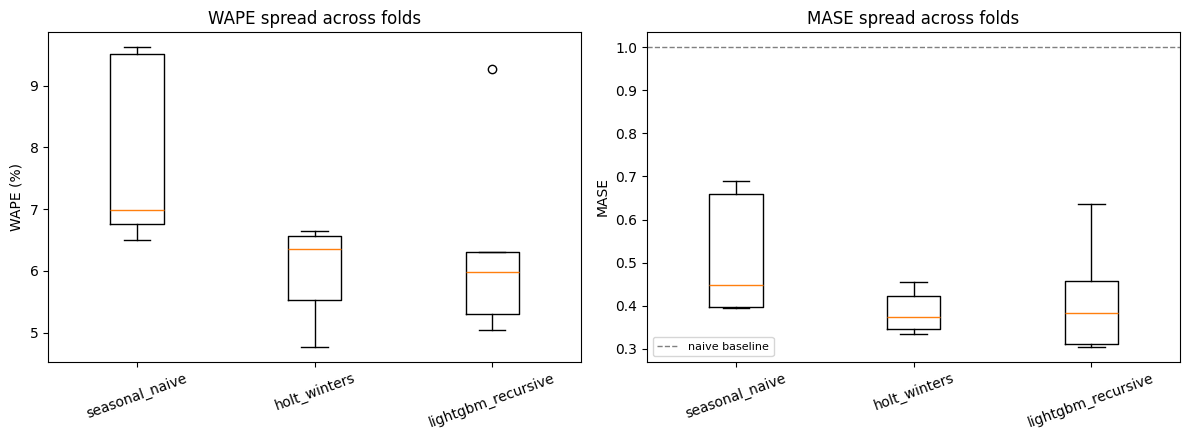

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
models_order = list(MODELS.keys())
axes[0].boxplot([scores_s4.loc[scores_s4.model == m, "wape"].values for m in models_order], tick_labels=models_order)
axes[0].set_ylabel("WAPE (%)"); axes[0].set_title("WAPE spread across folds"); axes[0].tick_params(axis="x", rotation=20)
axes[1].boxplot([scores_s4.loc[scores_s4.model == m, "mase"].values for m in models_order], tick_labels=models_order)
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="naive baseline")
axes[1].set_ylabel("MASE"); axes[1].set_title("MASE spread across folds"); axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

Holt-Winters comes out on top on the mean — 5.97% WAPE with a std of 0.80, versus 6.38% (std 1.70) for LightGBM and 7.88% (std 1.55) for naive. But it's not quite as simple as "Holt-Winters wins every fold" — LightGBM actually beats it on folds 0, 1 and 2 (5.30/5.03/5.97 vs 6.36/5.53/6.57), then falls apart on fold 3 (9.27 vs 6.64) and loses fold 4 too (6.31 vs 4.77). So Holt-Winters wins the average mostly because LightGBM has one bad fold dragging it down, not because it was ahead every single time.


What's more interesting is comparing this to Section 2. There, on one 60-day holdout, Holt-Winters was the worst of the three models by a wide margin — worse than naive, even. Here, across five folds, it's the best. That's a complete flip, and it's exactly the thing this whole exercise is supposed to catch: one holdout can easily land on an unlucky window for a model that's actually fine most of the time.


The spread itself tells its own story too — LightGBM's WAPE std is more than double Holt-Winters', almost entirely because of that one rough fold. If I only had one fold of LightGBM to go on, I'd trust that number a lot less than a single fold of Holt-Winters.

---
## Section 5 — Evaluation Metrics & Reporting
MAE and RMSE alone aren't comparable across series or against a baseline — a scale-free metric fixes that.

**Metric choice for this series: WAPE, not MAPE.** Riyadh/Grocery has no zero or near-zero days (see the summary below), so MAPE wouldn't blow up the way it would on a sparse series — but its daily volume still swings widely (roughly 400–2,400 units/day, including the Ramadan-style multi-day spikes Section 1.1 found in the STL residual). MAPE weights every day's *percentage* error equally regardless of that day's absolute volume, so a handful of low-volume off-peak days can dominate the average even when the model's absolute error there is small. WAPE instead scales the *total* absolute error by *total* actual demand, which better reflects how a retailer would actually judge "how far off was I, overall" — and it's also what makes the fold-to-fold comparisons in Section 4 meaningful, since every fold has a different average volume level.

In [ ]:
print(series.describe())
print(f"\ndays at or near zero: {(series < 10).sum()}")

count    1096.000000
mean      669.549270
std       206.684648
min       397.000000
25%       534.750000
50%       626.000000
75%       743.000000
max      2357.000000
Name: units_sold, dtype: float64

days at or near zero: 0


### Consolidated scorecard
MAE and RMSE (absolute units) alongside WAPE and MASE (scale-free), for every model, across the Section 4 backtest.

In [ ]:
summary_s4  

mae                 wape                mase  \
                         mean        std      mean       std      mean   
model                                                                    
holt_winters        34.691840   4.450515  5.972772  0.803387  0.386244   
lightgbm_recursive  37.524580  11.888255  6.377433  1.698038  0.418645   
seasonal_naive      46.414286  12.528783  7.875833  1.551424  0.517845   

                              
                         std  
model                         
holt_winters        0.051055  
lightgbm_recursive  0.136565  
seasonal_naive      0.145601

---
## Section 6 — Probabilistic Forecasting & Prediction Intervals
A point forecast that's off by 40 units, and a point forecast that also tells you it might be off by 40 units, are different tools for a planner deciding how much safety stock to hold. I'm building an 80% interval with quantile LightGBM — three models, each trained to hit a different quantile of the outcome distribution, reusing the exact recursive-forecast function from Section 3 with `quantile=` set.

80% interval -> coverage=88.3%   width=263.2 units


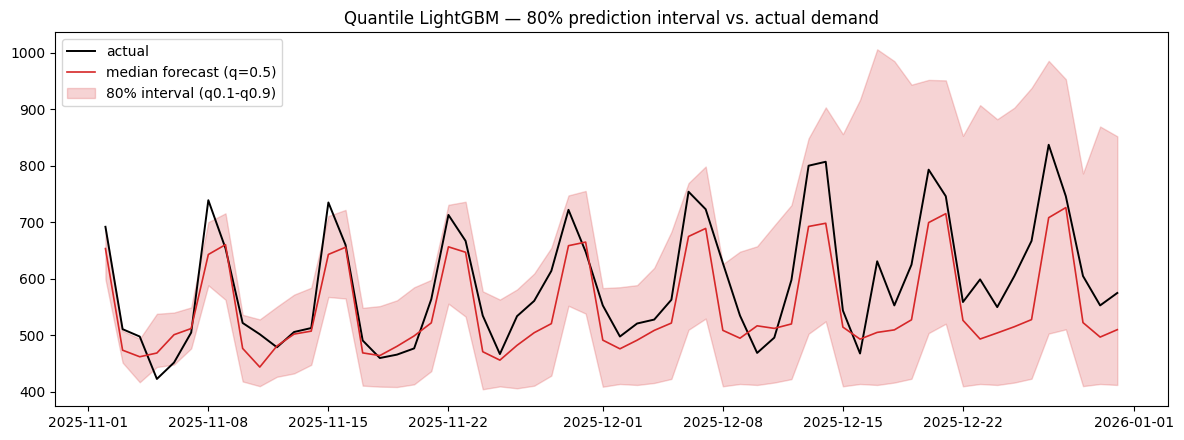

In [ ]:
q10_forecast = gbm_recursive_forecast(train_s2, HORIZON_S2, quantile=0.1)
q50_forecast = gbm_recursive_forecast(train_s2, HORIZON_S2, quantile=0.5)
q90_forecast = gbm_recursive_forecast(train_s2, HORIZON_S2, quantile=0.9)

interval_coverage = coverage(test_s2.values, q10_forecast, q90_forecast)
interval_w = interval_width(q10_forecast, q90_forecast)
print(f"80% interval -> coverage={interval_coverage:.1%}   width={interval_w:.1f} units")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test_s2.index, test_s2.values, color="black", linewidth=1.4, label="actual")
ax.plot(test_s2.index, q50_forecast, color="tab:red", linewidth=1.2, label="median forecast (q=0.5)")
ax.fill_between(test_s2.index, q10_forecast, q90_forecast, color="tab:red", alpha=0.2, label="80% interval (q0.1-q0.9)")
ax.set_title("Quantile LightGBM — 80% prediction interval vs. actual demand")
ax.legend()
plt.tight_layout()
plt.show()

Coverage landed at 88.3%, a bit above the 80% I was aiming for, so the interval is a little conservative rather than too tight. It's not the kind of interval that only "wins" by being enormous, though — at roughly 263 units wide against a series that typically runs 500–750 units a day, that's a fairly tight, usable band, not one that's hiding weak accuracy behind sheer width.

### 6.1 A second interval method — Prophet's native intervals
The capstone brief names three acceptable interval methods (conformal, Prophet, sktime); above is one of them (a quantile-objective GBM, the same family Lab 5 covers). Here's a second one, using Prophet's own built-in uncertainty interval, on the identical 60-day holdout — so coverage/width are directly comparable to the quantile-LightGBM numbers above.

In [ ]:
_pip_install("prophet", "cmdstanpy")

In [ ]:
from prophet import Prophet

prophet_train = train_s2.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(interval_width=0.8)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=HORIZON_S2, freq="D")


np.random.seed(RNG_SEED)
prophet_forecast = prophet_model.predict(future).tail(HORIZON_S2).reset_index(drop=True)

prophet_yhat = prophet_forecast["yhat"].values
prophet_lower = prophet_forecast["yhat_lower"].values
prophet_upper = prophet_forecast["yhat_upper"].values

prophet_coverage = coverage(test_s2.values, prophet_lower, prophet_upper)
prophet_width = interval_width(prophet_lower, prophet_upper)
print(f"Prophet 80% interval -> coverage={prophet_coverage:.1%}   width={prophet_width:.1f} units")
print(f"Prophet point-forecast MAE={mae(test_s2.values, prophet_yhat):.1f}  WAPE={wape(test_s2.values, prophet_yhat):.1f}%")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet 80% interval -> coverage=100.0%   width=341.2 units
Prophet point-forecast MAE=30.0  WAPE=5.1%


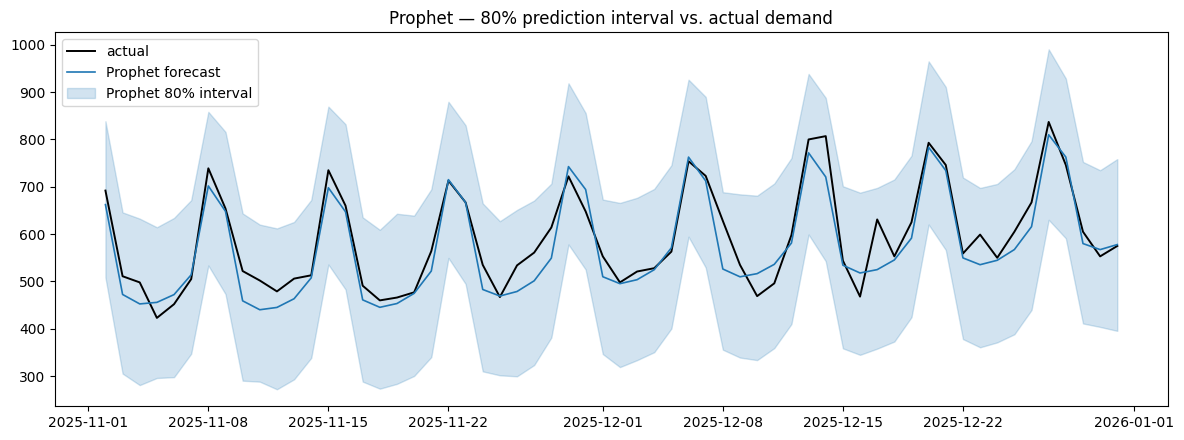

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test_s2.index, test_s2.values, color="black", linewidth=1.4, label="actual")
ax.plot(test_s2.index, prophet_yhat, color="tab:blue", linewidth=1.2, label="Prophet forecast")
ax.fill_between(test_s2.index, prophet_lower, prophet_upper, color="tab:blue", alpha=0.2, label="Prophet 80% interval")
ax.set_title("Prophet — 80% prediction interval vs. actual demand")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
interval_comparison = pd.DataFrame([
    {"method": "Quantile LightGBM", "coverage": interval_coverage, "width": interval_w},
    {"method": "Prophet", "coverage": prophet_coverage, "width": prophet_width},
]).set_index("method")
interval_comparison

,coverage,width
method,,
Quantile LightGBM,0.883333,263.160868
Prophet,1.000000,341.203498


Quantile LightGBM comes closer to the 80% target (88.3% vs Prophet's 100%) and it's narrower too — 263 units vs 341. Prophet technically never misses on this holdout, but that comes at the cost of a noticeably wider band, and for something like sizing safety stock, that extra width is extra inventory sitting around "just in case."


So between the two, I'd actually hand the LightGBM interval to a planner — it's closer to the target and tighter, even though Prophet's point forecast itself was more accurate (MAE 30.0 vs everything in Sections 2–3). That's the whole reason coverage and width need to be read together instead of judging an interval by how accurate the point forecast under it happens to be.

---
## Section 7 — Model Comparison & Documentation
A recommendation grounded in more than one axis, not just "lowest error wins".

Riyadh/Grocery has three full years of data, which is plenty for a classical model with a handful of parameters and enough for LightGBM's lag/rolling features to have real signal once the 28-day warm-up window is dropped — so history length doesn't rule any of the three model families out here.

On interpretability, SARIMAX and Holt-Winters both give a trend-plus-seasonality breakdown. LightGBM only gives split-count importances, which show what mattered but not really why demand moves the way it does. On intervals, SARIMAX and Holt-Winters both come with one built in; LightGBM needed the extra quantile step in Section 6 to get there at all. Compute-wise, the AIC search tried 216 SARIMAX candidates and LightGBM trained a few models nearly as fast, so at this scale compute isn't really the deciding factor — it would matter more if this were scaled up to all six region/category series at once.

The backtest in Section 4 is what actually settles it for me: Holt-Winters had the best mean WAPE (5.97%, MASE 0.386) and the smallest spread across folds (std 0.80), even though it was the worst model on Section 2's single holdout. LightGBM was close on the mean (6.38%) but much noisier fold to fold (std 1.70), mostly from one bad fold. Naive was clearly behind on both.

So my recommendation is Holt-Winters — it backtested best and most consistently. The one thing I'd flag is that Section 6 showed the quantile-LightGBM interval was better calibrated and tighter than Prophet's, so if interval precision specifically matters — like sizing safety stock — I'd consider pairing a quantile-LightGBM interval with the Holt-Winters point forecast rather than switching model families outright.